In [22]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC




DATASET_PATH = "/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/AI_method/Dataset/features_dataset.csv"
MODEL_DIR = "/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/AI_method/Models/"
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()

Dataset shape: (15240, 63)
label
0    7620
1    7620
Name: count, dtype: int64


,acq_duration_s,crest_factor,crest_factor_db,env_kurtosis,env_max,env_max_db,env_mean,env_median,env_p95,env_p99,...,wav_max_global,wav_max_mean,wav_max_median,wav_max_p95,wav_max_p99,wav_max_p999,wav_max_std,wav_n_windows,z_max,z_p999
0,0.1,3.950651,11.933374,0.231304,0.094893,-20.455345,0.021290,0.019999,0.041555,0.051496,...,5.494744,3.829967,3.781073,4.360973,4.890569,5.494744,0.337650,584,6.634781,3.813062
1,0.1,3.565468,11.042332,0.243270,0.087215,-21.188210,0.021681,0.020363,0.042304,0.052469,...,5.825295,3.858594,3.804785,4.538308,4.992332,5.436743,0.355041,584,5.809711,3.823672
2,0.1,3.744177,11.467127,0.228775,0.089313,-20.981735,0.021145,0.019872,0.041274,0.051149,...,5.334905,3.864484,3.794631,4.603650,5.072458,5.246806,0.374504,584,6.191473,3.788562
3,0.1,3.793008,11.579676,0.232052,0.089070,-21.005333,0.020813,0.019557,0.040625,0.050380,...,5.576868,3.804073,3.725236,4.508315,5.005722,5.576868,0.370972,584,6.280508,3.791567
4,0.1,4.015579,12.074963,0.243840,0.091780,-20.745024,0.020258,0.019032,0.039572,0.049055,...,6.048048,3.853242,3.786729,4.542543,4.972225,5.753872,0.372298,584,6.773983,3.810588


In [23]:
exclude_cols = [
    "timestamp",
    "label",
    "label_name",
]


numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    c for c in numeric_cols
    if c not in exclude_cols
]

X = df[feature_cols].replace([np.inf, -np.inf], np.nan)
y = df["label"].astype(int)

print("Nombre features:", len(feature_cols))
print(feature_cols)

Nombre features: 60
['acq_duration_s', 'crest_factor', 'crest_factor_db', 'env_kurtosis', 'env_max', 'env_max_db', 'env_mean', 'env_median', 'env_p95', 'env_p99', 'env_p999', 'env_p999_db', 'env_rms', 'env_sigma_robust', 'env_skewness', 'env_std', 'freq_center_hz', 'freq_center_mhz', 'gain', 'n_peaks', 'n_samples', 'peak_energy', 'peak_energy_db', 'peak_max', 'peak_mean', 'peak_rate_per_s', 'peak_threshold', 'rate_hz', 'repeat_idx', 'spec_flatness', 'spec_power_max_db', 'spec_power_mean_db', 'spec_power_p95_db', 'spec_power_p99_db', 'spec_power_std_db', 'wav_energy_global', 'wav_energy_global_db', 'wav_energy_mean', 'wav_energy_median', 'wav_energy_p95', 'wav_energy_p99', 'wav_energy_p999', 'wav_energy_std', 'wav_kurt_global', 'wav_kurt_mean', 'wav_kurt_median', 'wav_kurt_p95', 'wav_kurt_p99', 'wav_kurt_p999', 'wav_kurt_std', 'wav_max_global', 'wav_max_mean', 'wav_max_median', 'wav_max_p95', 'wav_max_p99', 'wav_max_p999', 'wav_max_std', 'wav_n_windows', 'z_max', 'z_p999']


In [24]:
groups = df["label"].astype(str) + "_rep_" + df["repeat_idx"].astype(str)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

df_train = df.iloc[train_idx]
df_test = df.iloc[test_idx]

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Train labels:\n", y_train.value_counts())
print("Test labels:\n", y_test.value_counts())

Train: (11430, 60)
Test : (3810, 60)
Train labels:
 label
1    6096
0    5334
Name: count, dtype: int64
Test labels:
 label
0    2286
1    1524
Name: count, dtype: int64


In [25]:
models = {
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=15,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", ExtraTreesClassifier(
            n_estimators=500,
            max_depth=15,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            random_state=42
        ))
    ]),

    "LogisticRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "SVM_RBF": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=3,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ]),
}

In [26]:
results = {}

for name, model in models.items():
    print("\n=================================================")
    print("Modèle:", name)
    print("=================================================")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)

    print("ROC AUC:", auc)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    results[name] = {
        "model": model,
        "auc": auc,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

best_name = max(results, key=lambda k: results[k]["auc"])
best_model = results[best_name]["model"]

print("\n===== Meilleur modèle =====")
print(best_name, "AUC =", results[best_name]["auc"])


Modèle: RandomForest
ROC AUC: 0.9993446931338308

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.98      0.98      1524

    accuracy                           0.99      3810
   macro avg       0.99      0.99      0.99      3810
weighted avg       0.99      0.99      0.99      3810

Confusion matrix:
[[2263   23]
 [  24 1500]]

Modèle: ExtraTrees
ROC AUC: 0.9994818971119425

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.99      0.98      1524

    accuracy                           0.99      3810
   macro avg       0.99      0.99      0.99      3810
weighted avg       0.99      0.99      0.99      3810

Confusion matrix:
[[2260   26]
 [  20 1504]]

Modèle: GradientBoosting
ROC AUC: 0.9993597626084141

Classification report:
              precision    recal

/home/yousef/Documents/testing_scripts/GEVernova/env/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


ROC AUC: 0.9986506361901613

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.99      0.98      1524

    accuracy                           0.99      3810
   macro avg       0.98      0.99      0.99      3810
weighted avg       0.99      0.99      0.99      3810

Confusion matrix:
[[2253   33]
 [  21 1503]]

===== Meilleur modèle =====
ExtraTrees AUC = 0.9994818971119425


In [27]:
import os
import joblib


os.makedirs(MODEL_DIR, exist_ok=True)

features_path = os.path.join(
    MODEL_DIR,
    "feature_columns.joblib"
)

joblib.dump(feature_cols, features_path)

print("Features sauvegardées :", features_path)


for name, res in results.items():

    model = res["model"]

    model_file = os.path.join(
        MODEL_DIR,
        f"{name}.joblib"
    )

    joblib.dump(model, model_file)

    print(
        f"Modèle sauvegardé : {name}"
        f" -> {model_file}"
    )


auc_dict = {
    name: float(results[name]["auc"])
    for name in results
}

auc_file = os.path.join(
    MODEL_DIR,
    "models_auc.json"
)

import json

with open(auc_file, "w") as f:
    json.dump(auc_dict, f, indent=4)

print("AUC sauvegardés :", auc_file)

Features sauvegardées : /home/yousef/Documents/testing_scripts/GEVernova/After_Aix/AI_method/Models/feature_columns.joblib
Modèle sauvegardé : RandomForest -> /home/yousef/Documents/testing_scripts/GEVernova/After_Aix/AI_method/Models/RandomForest.joblib
Modèle sauvegardé : ExtraTrees -> /home/yousef/Documents/testing_scripts/GEVernova/After_Aix/AI_method/Models/ExtraTrees.joblib
Modèle sauvegardé : GradientBoosting -> /home/yousef/Documents/testing_scripts/GEVernova/After_Aix/AI_method/Models/GradientBoosting.joblib
Modèle sauvegardé : LogisticRegression -> /home/yousef/Documents/testing_scripts/GEVernova/After_Aix/AI_method/Models/LogisticRegression.joblib
Modèle sauvegardé : SVM_RBF -> /home/yousef/Documents/testing_scripts/GEVernova/After_Aix/AI_method/Models/SVM_RBF.joblib
AUC sauvegardés : /home/yousef/Documents/testing_scripts/GEVernova/After_Aix/AI_method/Models/models_auc.json


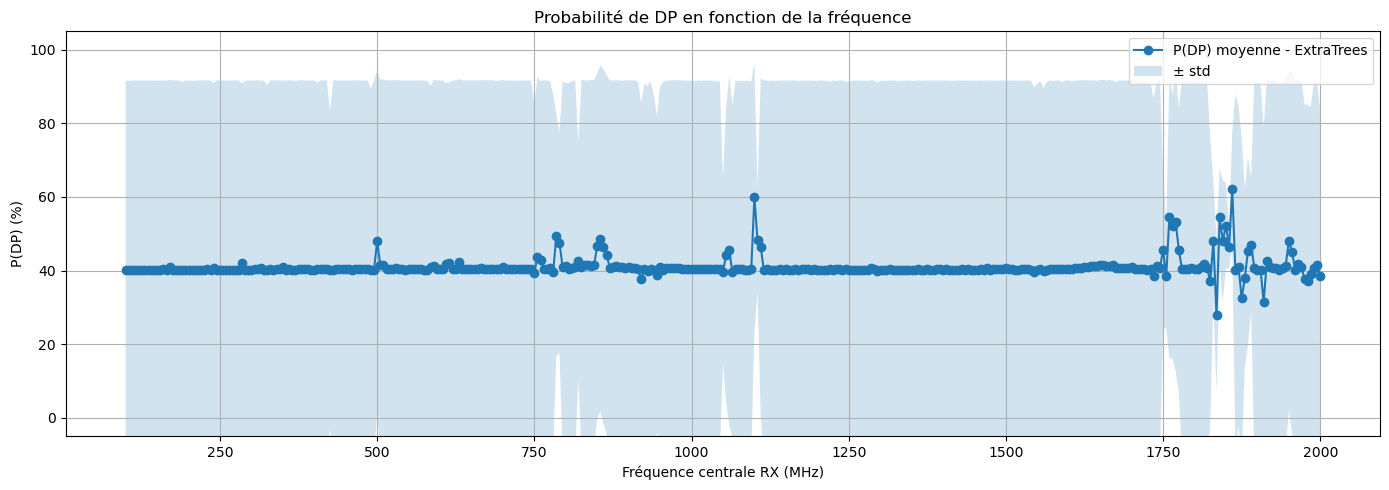

In [28]:
df_plot = df_test.copy()
df_plot["proba_dp"] = results[best_name]["y_proba"]
df_plot["pred"] = results[best_name]["y_pred"]


curve = (
    df_plot
    .groupby("freq_center_mhz")
    .agg(
        proba_dp_mean=("proba_dp", "mean"),
        proba_dp_std=("proba_dp", "std"),
        label_true=("label", "mean"),
        n=("proba_dp", "count")
    )
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(
    curve["freq_center_mhz"],
    100 * curve["proba_dp_mean"],
    marker="o",
    label=f"P(DP) moyenne - {best_name}"
)

plt.fill_between(
    curve["freq_center_mhz"],
    100 * (curve["proba_dp_mean"] - curve["proba_dp_std"].fillna(0)),
    100 * (curve["proba_dp_mean"] + curve["proba_dp_std"].fillna(0)),
    alpha=0.2,
    label="± std"
)

plt.title("Probabilité de DP en fonction de la fréquence")
plt.xlabel("Fréquence centrale RX (MHz)")
plt.ylabel("P(DP) (%)")
plt.ylim(-5, 105)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

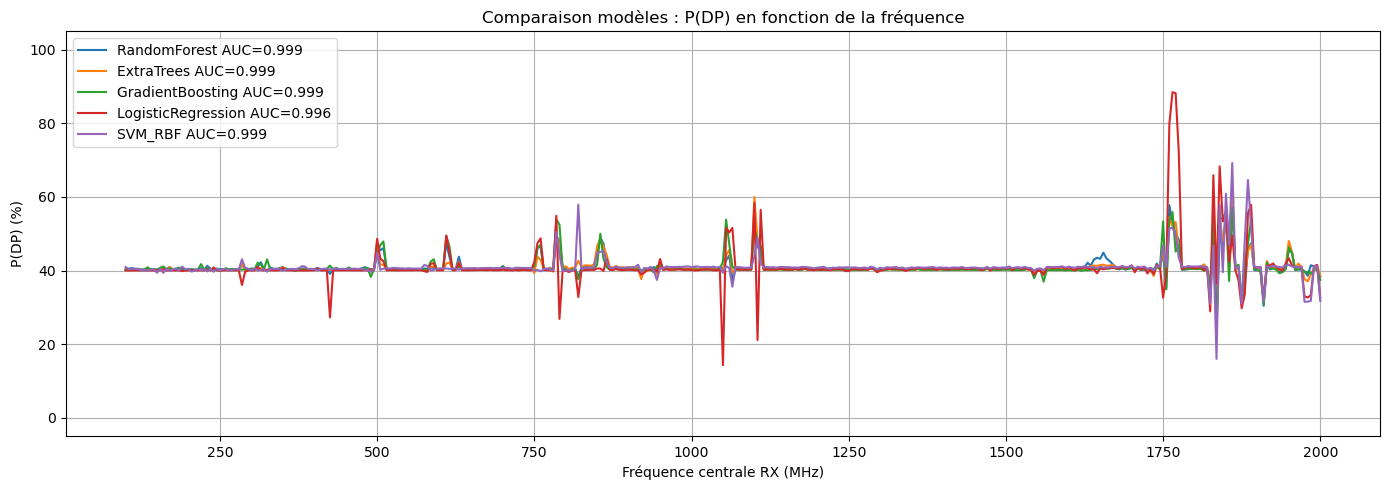

In [29]:
plt.figure(figsize=(14, 5))

for name, res in results.items():
    tmp = df_test.copy()
    tmp["proba_dp"] = res["y_proba"]

    curve_model = (
        tmp.groupby("freq_center_mhz")["proba_dp"]
        .mean()
        .reset_index()
    )

    plt.plot(
        curve_model["freq_center_mhz"],
        100 * curve_model["proba_dp"],
        label=f"{name} AUC={res['auc']:.3f}"
    )

plt.title("Comparaison modèles : P(DP) en fonction de la fréquence")
plt.xlabel("Fréquence centrale RX (MHz)")
plt.ylabel("P(DP) (%)")
plt.ylim(-5, 105)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

,feature,importance
22,peak_energy_db,0.222459
2,crest_factor_db,0.097657
24,peak_mean,0.081931
23,peak_max,0.079195
1,crest_factor,0.065718
5,env_max_db,0.061671
58,z_max,0.038016
55,wav_max_p999,0.032298
4,env_max,0.031442
50,wav_max_global,0.028384


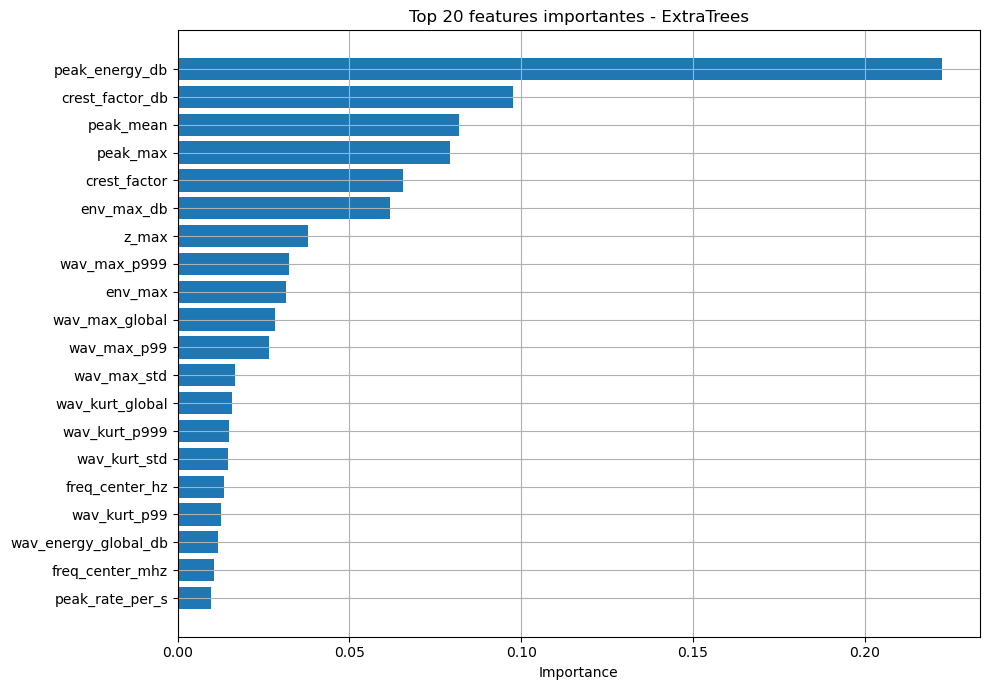

In [30]:
if best_name in ["RandomForest", "ExtraTrees"]:
    clf = best_model.named_steps["clf"]

    importances = pd.DataFrame({
        "feature": feature_cols,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importances.head(20))

    plt.figure(figsize=(10, 7))
    plt.barh(
        importances.head(20)["feature"][::-1],
        importances.head(20)["importance"][::-1]
    )
    plt.title(f"Top 20 features importantes - {best_name}")
    plt.xlabel("Importance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()